# Retrieval Analysis

This notebook is intended to show how the trained retrieval models can be evaluated. 
They are run on real measurement data and the results are compared to radiosonde observations and era5 data.

In [ ]:
%config InlineBackend.figure_format = 'svg'

import xarray as xr
import numpy as np
from IPython.display import Markdown, display

from openMWR.hatpro_data import calc_derived_quantities
from openMWR.run import run_model_list
from openMWR.models import Model
from openMWR.calc_errors import calculate_errors
from openMWR.plot import plot_err

DATA_DIR = 'data'

device = "cpu"

First, load the trained models.

In [10]:
site = 'munich_G5'

model_list = [Model.load('NN_opt', site, DATA_DIR), Model.load('MLR_opt', site, DATA_DIR), Model.load('NN_R17_opt', site, DATA_DIR)]

## Radiosonde Data Comparison

The analysis data set, created with the `openMWR.hatpro_data.create_analysis_dataset` function, is used for the analysis. 
This dataset contains the microwave radiometer measurements and the corresponding radiosonde observations. 
Depending on how it was created, the dataset may also contain RPG retrievals and simulated brightness temperatures from the radiosonde profiles.

In [ ]:
ds_an_data = xr.load_dataset(f'{DATA_DIR}/sites/{site}/analysis/analysis_data_radiosonde.nc')

# Only use data with day of month larger than 20. The rest was used to optimize the models.
ds_an_data = ds_an_data.where(ds_an_data['time'].dt.day > 20, drop=True)

# Select only the closest radiosonde station
ds_an_data = ds_an_data.sel(station='03715', drop=True)

ds_hatpro = ds_an_data.sel(data_source='hatpro', drop=True)
ds_raso = ds_an_data.sel(data_source='radiosonde', drop=True)

ds_hatpro

<xarray.Dataset> Size: 3MB
Dimensions:           (time: 253, height: 138, frq: 14)
Coordinates:
  * time              (time) datetime64[ns] 2kB 2024-11-21T10:45:00 ... 2025-...
  * height            (height) int64 1kB 0 10 25 50 75 ... 9700 9800 9900 10000
  * frq               (frq) float64 112B 22.24 23.04 23.84 ... 56.66 57.3 58.0
    synop             (time) datetime64[ns] 2kB 2024-11-21T12:00:00 ... 2025-...
Data variables: (12/25)
    lat               (time, height) float64 279kB nan nan nan ... nan nan nan
    lon               (time, height) float64 279kB nan nan nan ... nan nan nan
    p                 (time, height) float64 279kB 941.1 940.0 ... 244.7 nan
    T                 (time, height) float64 279kB 275.9 275.8 ... 216.1 nan
    wind_speed        (time, height) float64 279kB nan nan nan ... nan nan nan
    wind_dir          (time, height) float64 279kB nan nan nan ... nan nan nan
    ...                ...
    doy_sin           (time) float64 2kB -0.4822 -0.4822 ... -0.3735 -0.3575
    years_since_1970  (time) float64 2kB 54.89 54.89 54.89 ... 55.91 55.91 55.91
    rain_flag         (time) float64 2kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    azimuth_angle     (time) float32 1kB 0.0 0.0 0.0 0.0 ... 0.02 0.02 0.02 0.02
    elevation_angle   (time) float32 1kB 90.0 90.0 90.0 ... 89.98 89.98 89.98
    old_time          (time) datetime64[ns] 2kB 2024-11-21T10:45:00 ... 2025-...
Attributes:
    station_id:      03715
    station_name:    Oberschleißheim (Lustheim)
    station_height:  484
    station_lat:     48.2446
    station_lon:     11.5525

The next step is to apply the trained models to the measurement data.

In [ ]:
pred = run_model_list(model_list, ds_hatpro, device, site)

# Select only up to 10 km height for the analysis
pred = pred.sel(height=slice(0, 10000))

pred = calc_derived_quantities(pred)

# Add RPG retrievals to the prediction dataset for comparison
ds_hatpro_ret = ds_hatpro[['T', 'rh', 'ah', 'TD', 'iwv', 'lwc', 'lwp', 'p']].expand_dims(model=['RPG'])

pred =  xr.concat([ds_hatpro_ret, pred], dim='model', data_vars='minimal')

pred

<xarray.Dataset> Size: 9MB
Dimensions:           (model: 4, time: 253, height: 138, frq: 14)
Coordinates:
  * model             (model) object 32B 'RPG' 'NN_opt' 'MLR_opt' 'NN_R17_opt'
  * time              (time) datetime64[ns] 2kB 2024-11-21T10:45:00 ... 2025-...
  * height            (height) int64 1kB 0 10 25 50 75 ... 9700 9800 9900 10000
  * frq               (frq) float64 112B 22.24 23.04 23.84 ... 56.66 57.3 58.0
    synop             (time) datetime64[ns] 2kB 2024-11-21T12:00:00 ... 2025-...
Data variables: (12/28)
    T                 (model, time, height) float64 1MB 275.9 275.8 ... 215.2
    rh                (model, time, height) float64 1MB 50.26 50.48 ... 29.83
    ah                (model, time, height) float64 1MB 2.893 2.848 ... 0.007431
    TD                (model, time, height) float64 1MB 266.4 266.1 ... 206.0
    iwv               (model, time) float64 8kB 4.825 9.277 ... 10.61 14.75
    lwc               (model, time, height) float64 1MB 0.0 0.0 0.0 ... 0.0 0.0
    ...                ...
    azimuth_angle     (time) float32 1kB 0.0 0.0 0.0 0.0 ... 0.02 0.02 0.02 0.02
    elevation_angle   (time) float32 1kB 90.0 90.0 90.0 ... 89.98 89.98 89.98
    old_time          (time) datetime64[ns] 2kB 2024-11-21T10:45:00 ... 2025-...
    T_grad            (model, height, time) float64 1MB nan nan nan ... nan nan
    lwp_from_lwc      (model, time) float64 8kB nan nan nan nan ... 0.0 0.0 0.0
    iwv_from_ah       (model, time) float64 8kB nan nan nan ... 10.43 14.81
Attributes:
    station_id:      03715
    station_name:    Oberschleißheim (Lustheim)
    station_height:  484
    station_lat:     48.2446
    station_lon:     11.5525

Now, the predictions can be compared to the radiosonde observations. To do so, the `calculate_errors` function from `openMWR.calc_errors` is used.
This function computes error metrics between two xarray datasets. Here, the root mean square error (RMSE), mean absolute error (MAE), and mean error or bias (ME) are calculated.
These metrics are calculated as a mean over time (`errors_ds_height`) and as a mean over time and height (`errors_ds`).

In [17]:
var = ['T', 'rh']
error_types = ['RMSE', 'MAE', 'ME'] 
errors_ds, errors_ds_height = calculate_errors(pred[var], ds_raso[var], error_types = error_types) 

errors_ds_height

<xarray.Dataset> Size: 28kB
Dimensions:  (model: 4, height: 138, error: 3)
Coordinates:
  * model    (model) object 32B 'RPG' 'NN_opt' 'MLR_opt' 'NN_R17_opt'
  * height   (height) int64 1kB 0 10 25 50 75 100 ... 9600 9700 9800 9900 10000
  * error    (error) object 24B 'RMSE' 'MAE' 'ME'
Data variables:
    rh       (error, model, height) float64 13kB 8.705 8.661 ... -31.72 -31.49
    T        (error, model, height) float64 13kB 1.334 1.268 ... 0.615 0.6651

The results in `errors_ds_height` can be plotted with the simple `plot_err` function from `openMWR.plotting`.

## RMSE:

model,RPG,NN_opt,MLR_opt,NN_R17_opt
rh,20.143680,22.479396,25.636346,24.850292
T,1.533332,1.603442,1.731768,1.604466


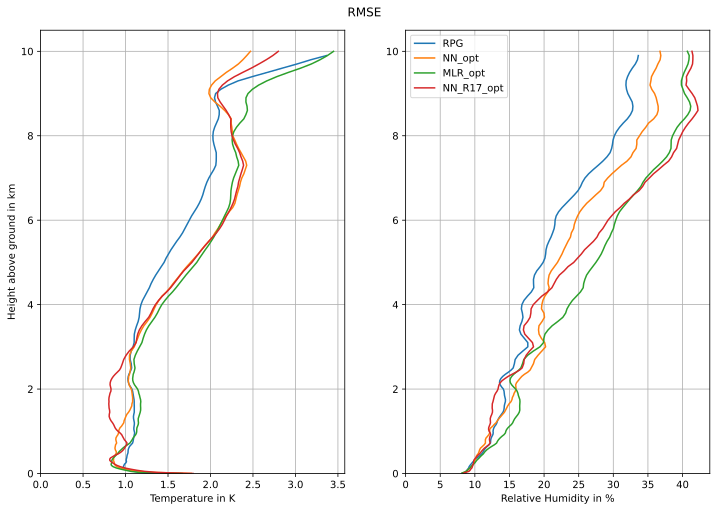

## MAE:

model,RPG,NN_opt,MLR_opt,NN_R17_opt
rh,14.965346,16.206437,18.583693,17.497841
T,1.116839,1.174671,1.261560,1.130477


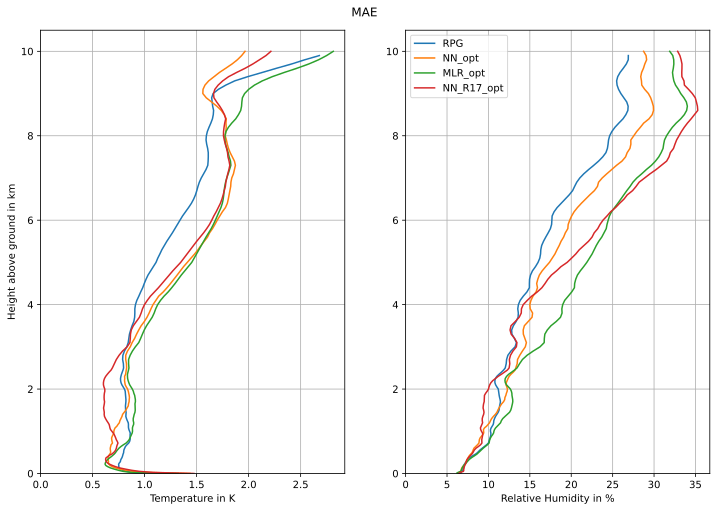

## ME:

model,RPG,NN_opt,MLR_opt,NN_R17_opt
rh,-7.307935,-11.740300,-11.529067,-12.319981
T,0.580791,0.700051,0.735504,0.138795


MAME:

model,RPG,NN_opt,MLR_opt,NN_R17_opt
T,0.583289,0.700051,0.735504,0.221145
rh,7.371645,11.740300,11.529067,12.715654


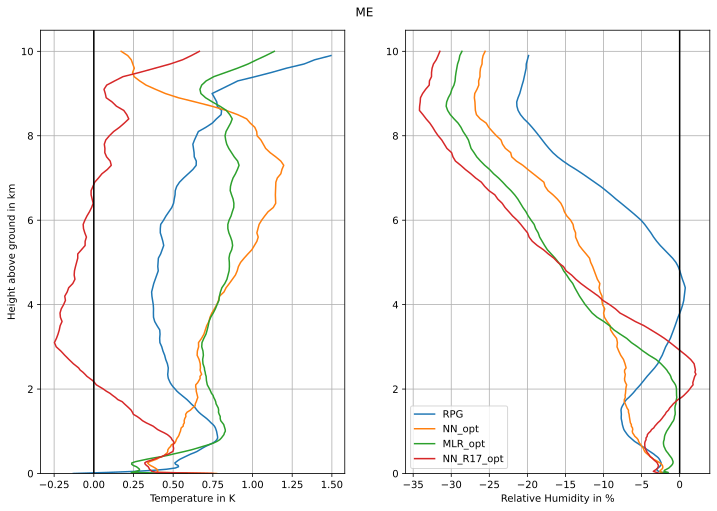

In [ ]:
for error_type in error_types:
    display(Markdown(f"## {error_type}:"))
    display(errors_ds.sel(error=error_type, drop=True).to_dataframe().T)
    
    if error_type == 'ME':
        display(Markdown(f"## MAME:"))
        display(np.abs(errors_ds_height.sel(error=error_type, drop=True)).mean(dim='height')[var].to_dataframe().T)
    
    plot_err(errors_ds_height.sel(error=error_type), err=error_type)

## Era5 Data Comparison

The same analysis can be performed using ERA5 data instead of radiosonde observations.
For this purpose, the ERA5 dataset created with the `create_analysis_dataset_from_forward_calc` method from the `openMWR.era5.ERA5Processor` class is used.
The rest of the steps are the same as for the radiosonde comparison.

In [14]:
ds_an_data = xr.load_dataset(f'data/sites/{site}/analysis/analysis_data_era5.nc')

ds_an_data = ds_an_data.where(ds_an_data['time'].dt.day > 20, drop=True)

ds_hatpro = ds_an_data.sel(data_source='hatpro', drop=True)
ds_raso = ds_an_data.sel(data_source='era5', drop=True)

ds_hatpro

<xarray.Dataset> Size: 5MB
Dimensions:           (time: 710, height: 138, frq: 14)
Coordinates:
  * time              (time) datetime64[ns] 6kB 2024-11-21 ... 2025-11-30T20:...
  * height            (height) int64 1kB 0 10 25 50 75 ... 9700 9800 9900 10000
  * frq               (frq) float64 112B 22.24 23.04 23.84 ... 56.66 57.3 58.0
Data variables: (12/20)
    p                 (time, height) float64 784kB 943.4 942.2 ... 243.6 nan
    rh                (time, height) float64 784kB 72.22 71.34 ... 38.36 nan
    lwc               (time, height) float64 784kB 0.0 0.0 0.0 ... 0.0 0.0 nan
    T                 (time, height) float64 784kB 275.2 275.1 ... 219.6 nan
    ah                (time, height) float64 784kB 3.339 3.302 ... 0.01085 nan
    TD                (time, height) float64 784kB 268.2 268.1 ... 208.9 nan
    ...                ...
    years_since_1970  (time) float64 6kB 54.89 54.89 54.89 ... 55.91 55.91 55.91
    rain_flag         (time) float64 6kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    azimuth_angle     (time) float32 3kB 0.0 0.0 0.0 0.0 ... 0.02 0.02 0.02 0.02
    elevation_angle   (time) float32 3kB 90.0 90.0 90.0 ... 89.98 89.98 89.98
    TB_IR             (time) float32 3kB 242.1 263.2 246.6 ... 256.6 263.7 270.7
    old_time          (time) datetime64[ns] 6kB 2024-11-20T23:59:00 ... 2025-...
Attributes:
    latitude:   48.25
    longitude:  11.5

In [ ]:
pred = run_model_list(model_list, ds_hatpro, device, site)

pred = pred.sel(height=slice(0, 10000))

pred = calc_derived_quantities(pred)

ds_hatpro_ret = ds_hatpro[['T', 'rh', 'ah', 'TD', 'iwv', 'lwc', 'lwp', 'p']].expand_dims(model=['RPG'])

pred =  xr.concat([ds_hatpro_ret, pred], dim='model', data_vars='minimal')

pred

<xarray.Dataset> Size: 22MB
Dimensions:           (model: 4, time: 710, height: 138, frq: 14)
Coordinates:
  * model             (model) object 32B 'RPG' 'NN_opt' 'MLR_opt' 'NN_R17_opt'
  * time              (time) datetime64[ns] 6kB 2024-11-21 ... 2025-11-30T20:...
  * height            (height) int64 1kB 0 10 25 50 75 ... 9700 9800 9900 10000
  * frq               (frq) float64 112B 22.24 23.04 23.84 ... 56.66 57.3 58.0
Data variables: (12/23)
    T                 (model, time, height) float64 3MB 275.2 275.1 ... 217.7
    rh                (model, time, height) float64 3MB 72.22 71.34 ... 18.71
    ah                (model, time, height) float64 3MB 3.339 3.302 ... 0.006234
    TD                (model, time, height) float64 3MB 268.2 268.1 ... 204.9
    iwv               (model, time) float64 23kB 5.215 6.394 ... 16.01 15.21
    lwc               (model, time, height) float64 3MB 0.0 0.0 0.0 ... 0.0 0.0
    ...                ...
    elevation_angle   (time) float32 3kB 90.0 90.0 90.0 ... 89.98 89.98 89.98
    TB_IR             (time) float32 3kB 242.1 263.2 246.6 ... 256.6 263.7 270.7
    old_time          (time) datetime64[ns] 6kB 2024-11-20T23:59:00 ... 2025-...
    T_grad            (model, height, time) float64 3MB nan nan nan ... nan nan
    lwp_from_lwc      (model, time) float64 23kB nan nan nan nan ... 0.0 0.0 0.0
    iwv_from_ah       (model, time) float64 23kB nan nan nan ... 16.62 15.71
Attributes:
    latitude:   48.25
    longitude:  11.5

### RMSE

model,RPG,NN_opt,MLR_opt,NN_R17_opt
rh,20.143680,22.479396,25.636346,24.850292
T,1.533332,1.603442,1.731768,1.604466


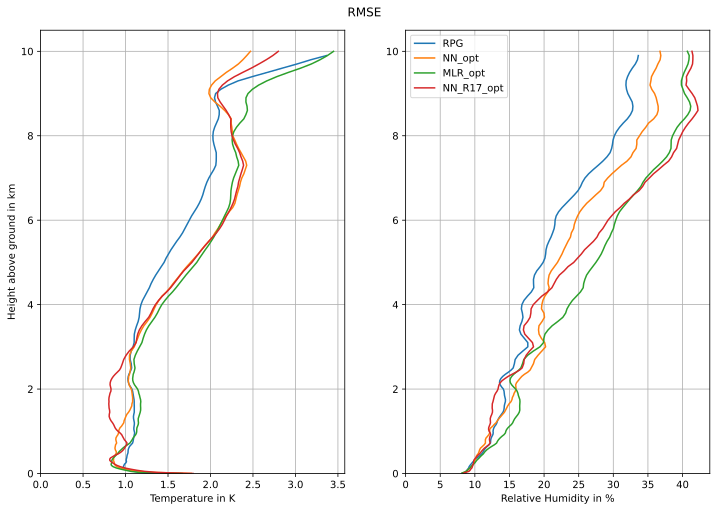

### MAE

model,RPG,NN_opt,MLR_opt,NN_R17_opt
rh,14.965346,16.206437,18.583693,17.497841
T,1.116839,1.174671,1.261560,1.130477


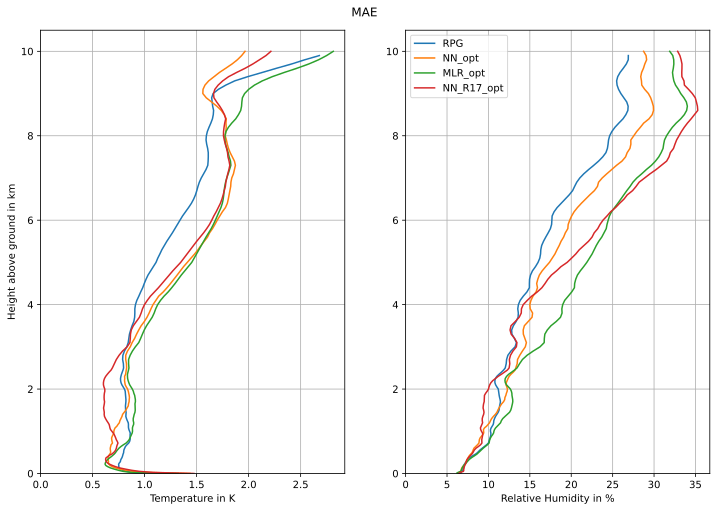

### ME

model,RPG,NN_opt,MLR_opt,NN_R17_opt
rh,-7.307935,-11.740300,-11.529067,-12.319981
T,0.580791,0.700051,0.735504,0.138795


MAME:

model,RPG,NN_opt,MLR_opt,NN_R17_opt
T,0.583289,0.700051,0.735504,0.221145
rh,7.371645,11.740300,11.529067,12.715654


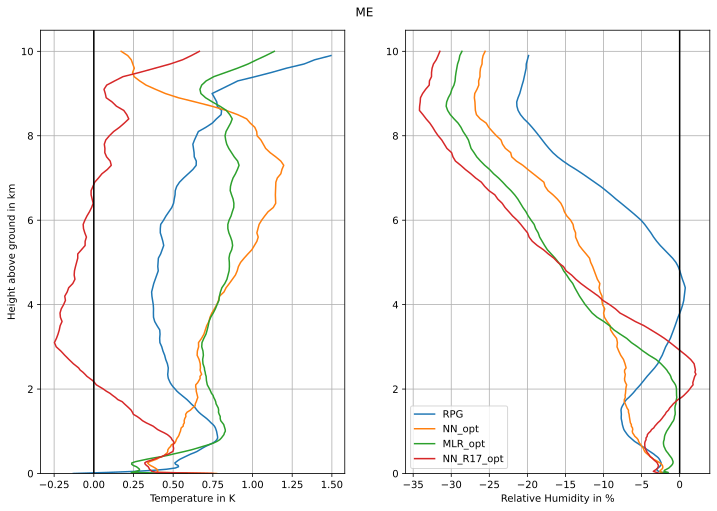

In [16]:
var = ['T', 'rh']
error_types = ['RMSE', 'MAE', 'ME'] 
errors_ds, errors_ds_height = calculate_errors(pred[var], ds_raso[var], error_types = error_types) 

for error_type in error_types:
    display(Markdown(f"### {error_type}"))
    display(errors_ds.sel(error=error_type, drop=True).to_dataframe().T)
    if error_type == 'ME':
        display(Markdown(f"MAME:"))
        display(np.abs(errors_ds_height.sel(error=error_type, drop=True)).mean(dim='height')[var].to_dataframe().T)
    colors = plot_err(errors_ds_height.sel(error=error_type), err=error_type) #, zero_xlim=False